In [ ]:
## import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import zipfile
from tensorflow.keras.utils import image_dataset_from_directory
import  tensorflow as tf
from tensorflow.keras.metrics import Precision, Accuracy, Recall # type: ignore
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
## Set the environment to you 16 cores for parrallel processing
os.environ["TF_NUM_INTRAOP_THREADS"] ="16"

In [ ]:
## unzip the zipped_files
with zipfile.ZipFile("./imageset.zip", "r") as zip_ref:
    zip_ref.extractall("./dataset")

In [4]:
## Load the trainset
data_path = "./dataset/imageset/train"
batch_size = 32
image_size = (256,256)

train,val = image_dataset_from_directory(directory=data_path,
                                    label_mode="categorical",
                                    batch_size=batch_size,
                                    image_size=image_size, 
                                    validation_split =0.1, subset = "both",
                                    seed = 42)

## Load the test set

test_path = "./dataset/imageset/val"
test = image_dataset_from_directory(directory=test_path,
                                    label_mode="categorical",
                                    batch_size=batch_size,
                                    image_size=image_size)

Found 9469 files belonging to 10 classes.
Using 8523 files for training.
Using 946 files for validation.
Found 3925 files belonging to 10 classes.


In [4]:
### Count the number batch size in train and validation set
print(f"The number of batches in train_set is: {len(train)} batches\
    \nThe number of batches in val_set is: {len(val)} batches")

The number of batches in train_set is: 267 batches    
The number of batches in val_set is: 30 batches


In [5]:
## Check for the minimum and maximum pixel value

min_val = []
max_val = []

for image_, _ in train:
    batch_min = tf.reduce_min(image_)
    batch_max = tf.reduce_max(image_)
    min_val.append(batch_min)
    max_val.append(batch_max)
    
print(f"The minumal pixel value is {min(min_val)}\
    \nThe maximum pixel value is {max(max_val)}\
    \nThe imaget type is {image_.dtype}")

The minumal pixel value is 0.0    
The maximum pixel value is 255.0    
The imaget type is <dtype: 'float32'>


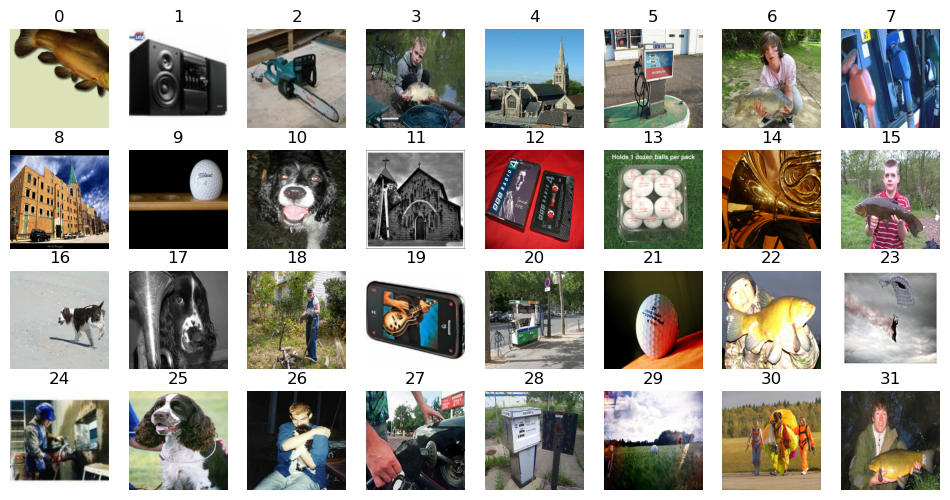

In [ ]:
## Scale the dataset to range [0.0, 1.0] for imshow
train_scaled = train.map(lambda x,y: (x/255.0, y))
val_scaled = val.map(lambda x,y: (x/255.0, y))

## fetch the first batch of images
batch = train_scaled.as_numpy_iterator().next()

## plot the first batch of images
plt.figure(figsize=(12,6))
for idx,image in enumerate(batch[0][:32]):
    ax = plt.subplot(4,8, idx +1)
    plt.imshow(image)
    plt.title(f"{idx}")
    plt.axis("off")
    

In [ ]:
## create the prepocess pipeleine to be used for the pretrained model - Transfer learning
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
    ])

## Preprocess the trainset, validation and test set
train_new = train.map(lambda x, y: (preprocess(x),y))
val_new = val.map(lambda x, y: (preprocess(x),y))
test_clean = test.map(lambda x, y: (preprocess(x),y))

In [ ]:
## Fetch the pretrained model for the base model
base_model = tf.keras.applications.xception.Xception(weights="imagenet", include_top=False)

## Add the top layers for the specific task - multilabeli-image classification
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(10, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)


### Freeze the layers of the base model to prevent training
for layer in base_model.layers:
    layer.trainable = False

## Compile the model 
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1,momentum=0.9)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics = ["accuracy"])

## train model for few epochs (3) to train the top layers
history_new = model.fit(train_new, validation_data=val_new, epochs=3)

Epoch 1/3
267/267 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.9398 - loss: 0.2061 - val_accuracy: 0.9873 - val_loss: 0.0410
Epoch 2/3
267/267 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.9952 - loss: 0.0160 - val_accuracy: 0.9894 - val_loss: 0.0511
Epoch 3/3
267/267 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.9986 - loss: 0.0060 - val_accuracy: 0.9873 - val_loss: 0.0431


In [ ]:

## Unfreexe some toplayers of the base model to be trainable to improve model performance
for layer in base_model.layers[56:]:
    layer.trainable = True
    
   
## Recompile the model while reducing the learning rate 
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics = ["accuracy"])

## Train the model
history_new = model.fit(train_new, validation_data=val_new, epochs=10)

    

Epoch 1/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1209s 4s/step - accuracy: 0.9788 - loss: 0.0752 - val_accuracy: 0.9810 - val_loss: 0.0683
Epoch 2/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1170s 4s/step - accuracy: 0.9938 - loss: 0.0181 - val_accuracy: 0.9820 - val_loss: 0.0688
Epoch 3/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1173s 4s/step - accuracy: 0.9974 - loss: 0.0078 - val_accuracy: 0.9841 - val_loss: 0.0508
Epoch 4/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1169s 4s/step - accuracy: 0.9989 - loss: 0.0051 - val_accuracy: 0.9863 - val_loss: 0.0498
Epoch 5/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1174s 4s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9863 - val_loss: 0.0503
Epoch 6/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1224s 5s/step - accuracy: 1.0000 - loss: 6.2969e-04 - val_accuracy: 0.9852 - val_loss: 0.0459
Epoch 7/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1190s 4s/step - accuracy: 1.0000 - loss: 5.2573e-04 - val_accuracy: 0.9863 - val_loss: 0.0475
Epoch 8/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 1177s 4s/step - accuracy: 0.9999 - loss: 5

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

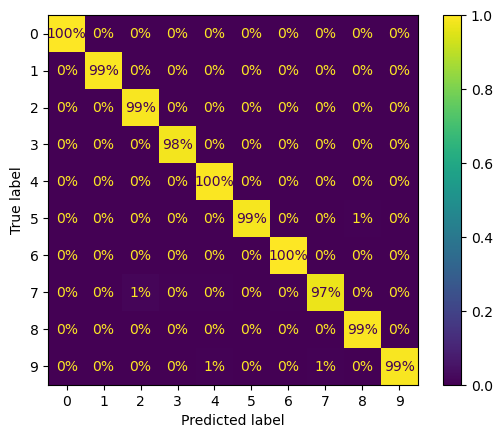

In [ ]:
# Model Evaluation


##Model Metrics 
accuracy = Accuracy()
precision = Precision()
recall = Recall()
# Collect true and predicted labels
true_labels = []
predicted_labels = []

for batch in test_clean:
  features, target_ = batch
  target = tf.argmax(target_, axis=1)
  target_predicted = model.predict(features)
  predicted_class = tf.argmax(target_predicted, axis = 1)
  true_labels.extend(target)
  predicted_labels.extend(predicted_class)
  accuracy.update_state(target, predicted_class)
  precision.update_state(target, predicted_class)
  recall.update_state(target, predicted_class)

# Print Evaluation result
print(f' Model Accuracy: {accuracy.result():.4f}, Model Precision: {precision.result():.4f}, Model Recall: {recall.result():.4f}')


# Generate confusion matrix display
confusion_display = ConfusionMatrixDisplay.from_predictions(np.array(true_labels),
                                                            np.array(predicted_labels),
                                                                     normalize="true",
                                                                     values_format=".0%")
confusion_display